<a href="https://www.kaggle.com/code/kenanavar/shap-ml-r-2-85-rmse-6-13?scriptVersionId=239904493" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
df_shap = pd.read_csv('/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv')
df_shap.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df_shap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
df_shap.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

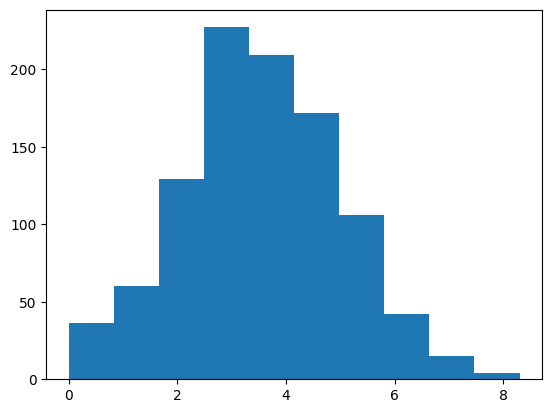

In [6]:
plt.hist(df_shap['study_hours_per_day'],bins=10)
plt.show()

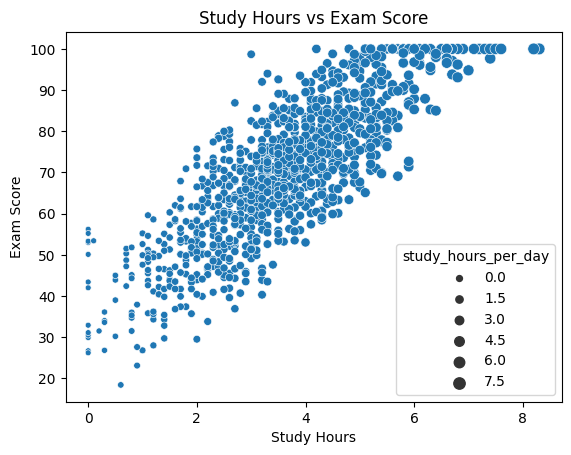

In [7]:
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df_shap, size = 'study_hours_per_day')
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

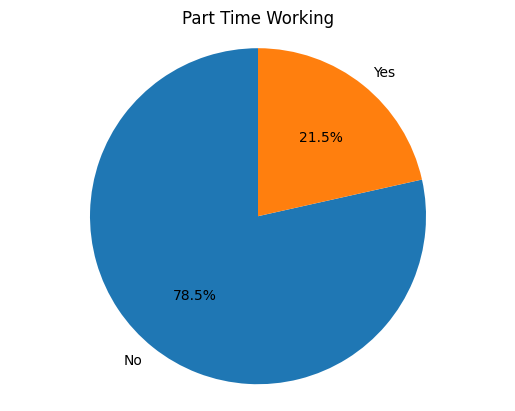

In [8]:
sizes = df_shap['part_time_job'].value_counts()
labels = sizes.index

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Part Time Working')
plt.axis('equal')  # Daire gibi görünmesi için
plt.show()

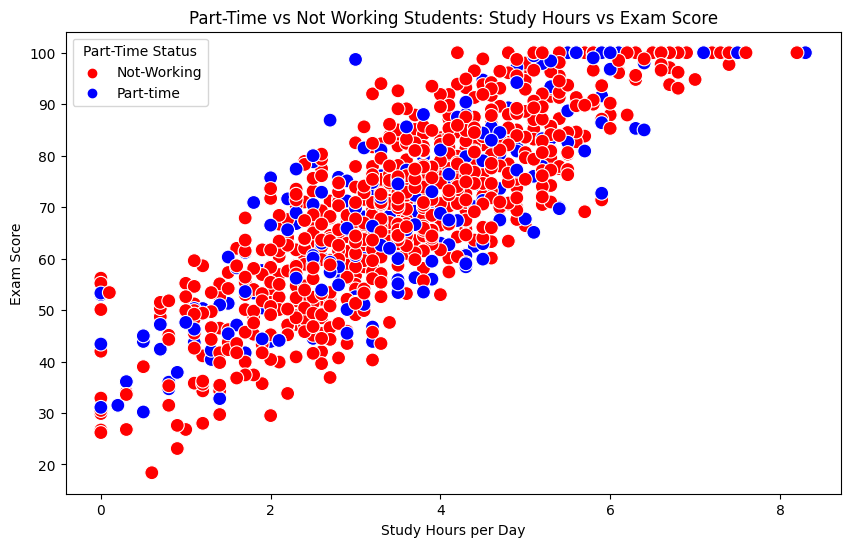

In [9]:
df_shap['part_time_job'] = df_shap['part_time_job'].map({'Yes': 'Part-time', 'No': 'Not-Working'})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df_shap, hue='part_time_job', palette=['red', 'blue'], s=100)
plt.title('Part-Time vs Not Working Students: Study Hours vs Exam Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.legend(title='Part-Time Status')
plt.show()


In [10]:
print(df_shap['parental_education_level'].unique())
print(df_shap['mental_health_rating'].unique())

['Master' 'High School' 'Bachelor' nan]
[ 8  1  4 10  3  9  7  5  2  6]


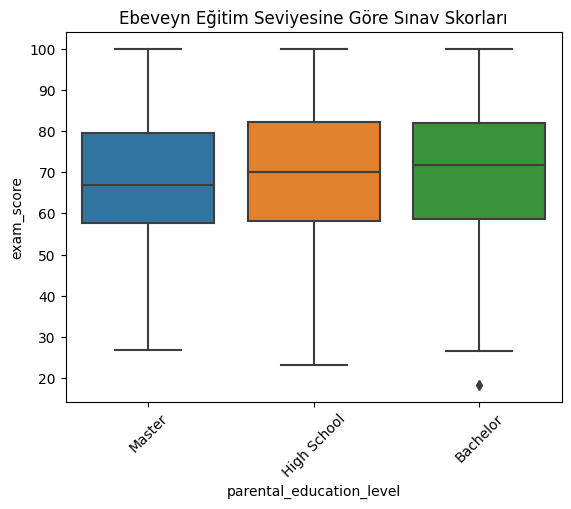

In [11]:
sns.boxplot(data=df_shap, x='parental_education_level', y='exam_score')
plt.xticks(rotation=45)
plt.title('Ebeveyn Eğitim Seviyesine Göre Sınav Skorları')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


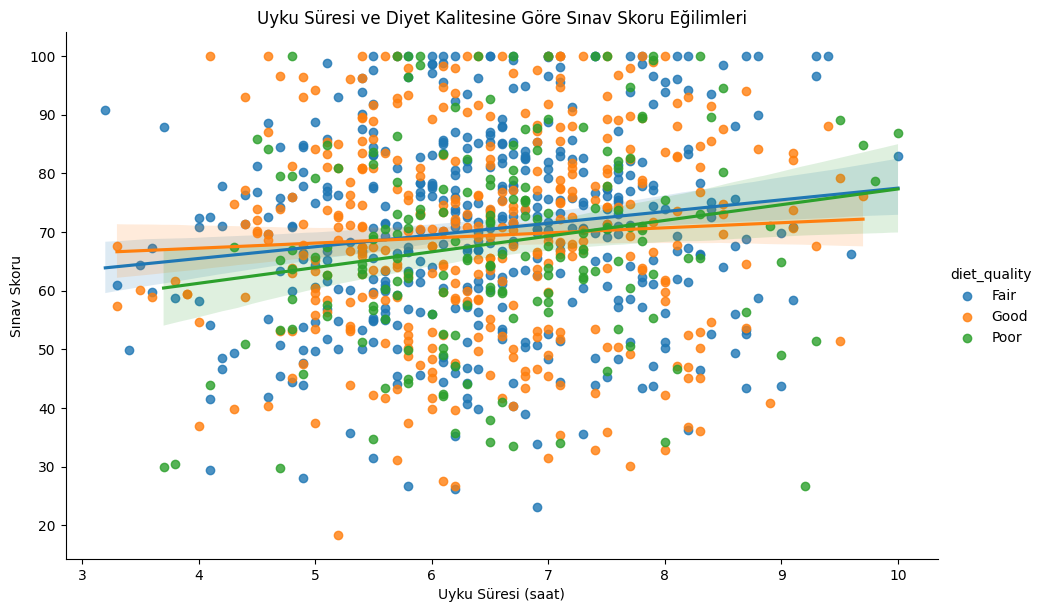

In [12]:
sns.lmplot(data=df_shap, x='sleep_hours', y='exam_score', hue='diet_quality', aspect=1.6, height=6)
plt.title('Uyku Süresi ve Diyet Kalitesine Göre Sınav Skoru Eğilimleri')
plt.xlabel('Uyku Süresi (saat)')
plt.ylabel('Sınav Skoru')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


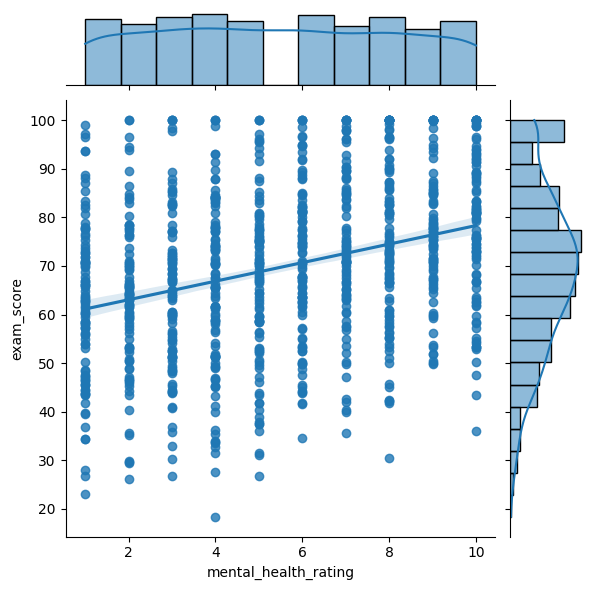

In [13]:
sns.jointplot(data=df_shap, x='mental_health_rating', y='exam_score', kind='reg')

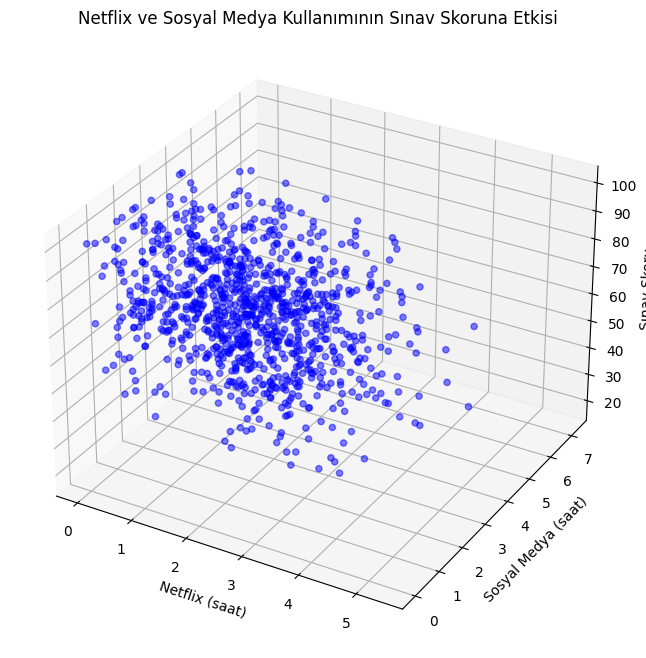

In [14]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_shap['netflix_hours'], df_shap['social_media_hours'], df_shap['exam_score'], c='blue', alpha=0.5)
ax.set_xlabel('Netflix (saat)')
ax.set_ylabel('Sosyal Medya (saat)')
ax.set_zlabel('Sınav Skoru')
ax.set_title('Netflix ve Sosyal Medya Kullanımının Sınav Skoruna Etkisi')

plt.show()

In [15]:
def create_interaction_features(df_shap):
    df_shap_copy = df_shap.copy()

    numeric_pairs = [
        ('study_hours_per_day', 'exercise_frequency'),
        ('social_media_hours', 'netflix_hours'),
        ('sleep_hours', 'mental_health_rating'),
        ('sleep_hours', 'study_hours_per_day'),
        ('sleep_hours', 'exercise_frequency')
    ]

    for col1, col2 in numeric_pairs:

        df_shap_copy[f'interact_{col1}_{col2}'] = df_shap_copy[col1] * df_shap_copy[col2]

        df_shap_copy[f'diff_{col1}_{col2}'] = df_shap_copy[col1] - df_shap_copy[col2]

        df_shap_copy[f'ratio_{col1}_{col2}'] = df_shap_copy[col1] / (df_shap_copy[col2] + 1e-5)  # küçük sayı ile sıfır bölmesini engelliyoruz

    return df_shap_copy

In [16]:
df_shap_new = create_interaction_features(df_shap)
df_shap_new.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,...,ratio_social_media_hours_netflix_hours,interact_sleep_hours_mental_health_rating,diff_sleep_hours_mental_health_rating,ratio_sleep_hours_mental_health_rating,interact_sleep_hours_study_hours_per_day,diff_sleep_hours_study_hours_per_day,ratio_sleep_hours_study_hours_per_day,interact_sleep_hours_exercise_frequency,diff_sleep_hours_exercise_frequency,ratio_sleep_hours_exercise_frequency
0,S1000,23,Female,0.0,1.2,1.1,Not-Working,85.0,8.0,Fair,...,1.090899,64.0,0.0,0.999999,0.00,8.0,800000.000000,48.0,2.0,1.333331
1,S1001,20,Female,6.9,2.8,2.3,Not-Working,97.3,4.6,Good,...,1.217386,36.8,-3.4,0.574999,31.74,-2.3,0.666666,27.6,-1.4,0.766665
2,S1002,21,Male,1.4,3.1,1.3,Not-Working,94.8,8.0,Poor,...,2.384597,8.0,7.0,7.999920,11.20,6.6,5.714245,8.0,7.0,7.999920
3,S1003,23,Female,1.0,3.9,1.0,Not-Working,71.0,9.2,Poor,...,3.899961,9.2,8.2,9.199908,9.20,8.2,9.199908,36.8,5.2,2.299994
4,S1004,19,Female,5.0,4.4,0.5,Not-Working,90.9,4.9,Fair,...,8.799824,4.9,3.9,4.899951,24.50,-0.1,0.979998,14.7,1.9,1.633328


In [17]:
X = df_shap_new.drop(columns=['exam_score'])
y = df_shap_new['exam_score']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

mi_scores = mutual_info_regression(X_encoded, y)
mi_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'mutual_info_score': mi_scores
}).sort_values(by='mutual_info_score', ascending=False).reset_index(drop=True)

print(mi_df)

                                            feature  mutual_info_score
0          interact_sleep_hours_study_hours_per_day           0.550058
1                               study_hours_per_day           0.546882
2   interact_study_hours_per_day_exercise_frequency           0.263541
3              diff_sleep_hours_study_hours_per_day           0.175386
4                              mental_health_rating           0.106488
5       diff_study_hours_per_day_exercise_frequency           0.098609
6      ratio_study_hours_per_day_exercise_frequency           0.097132
7             ratio_sleep_hours_study_hours_per_day           0.081325
8            ratio_sleep_hours_mental_health_rating           0.076352
9         interact_sleep_hours_mental_health_rating           0.061655
10                                      sleep_hours           0.041182
11          interact_sleep_hours_exercise_frequency           0.034841
12                         parental_education_level           0.021926
13    

In [18]:
X = X_encoded
y = df_shap_new['exam_score']

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns)

In [19]:
X = X_encoded
y = df_shap_new['exam_score']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

fi_series = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

In [20]:
def get_top_features(mi_scores, fi_scores, top_n=10):
    
    mi_df = pd.DataFrame({'feature': mi_scores.index, 'mutual_info': mi_scores.values})
    fi_df = pd.DataFrame({'feature': fi_scores.index, 'feature_importance': fi_scores.values})
    
    df = pd.merge(mi_df, fi_df, on='feature', how='inner')
    
    scaler = MinMaxScaler()
    df[['mi_scaled', 'fi_scaled']] = scaler.fit_transform(df[['mutual_info', 'feature_importance']])
    
    df['total_score'] = df['mi_scaled'] + df['fi_scaled']
    
    df_sorted = df.sort_values('total_score', ascending=False).reset_index(drop=True)
    
    return df_sorted.head(top_n)[['feature', 'mutual_info', 'feature_importance', 'total_score']]

top_features = get_top_features(mi_series, fi_series, top_n=10)
print(top_features.to_string(index=False))

                                        feature  mutual_info  feature_importance  total_score
       interact_sleep_hours_study_hours_per_day     0.549975            0.510979     1.991760
                            study_hours_per_day     0.554544            0.200027     1.390609
interact_study_hours_per_day_exercise_frequency     0.266567            0.026841     0.531902
           diff_sleep_hours_study_hours_per_day     0.168719            0.002500     0.307751
                           mental_health_rating     0.101557            0.020575     0.222062
         ratio_sleep_hours_mental_health_rating     0.077027            0.041370     0.218581
      interact_sleep_hours_mental_health_rating     0.061698            0.039874     0.188006
    diff_study_hours_per_day_exercise_frequency     0.099300            0.003165     0.183873
   ratio_study_hours_per_day_exercise_frequency     0.089360            0.002937     0.165499
          ratio_sleep_hours_study_hours_per_day     0.082605

In [21]:
print(type(top_features))

<class 'pandas.core.frame.DataFrame'>


In [22]:
top_features = get_top_features(mi_series, fi_series, top_n=10)
print(top_features.head())

top_10_features = top_features['feature'].tolist()

                                           feature  mutual_info  \
0         interact_sleep_hours_study_hours_per_day     0.549975   
1                              study_hours_per_day     0.554544   
2  interact_study_hours_per_day_exercise_frequency     0.266567   
3             diff_sleep_hours_study_hours_per_day     0.168719   
4                             mental_health_rating     0.101557   

   feature_importance  total_score  
0            0.510979     1.991760  
1            0.200027     1.390609  
2            0.026841     0.531902  
3            0.002500     0.307751  
4            0.020575     0.222062  


In [23]:
original_cols = [col for col in df_shap_new.columns if not col.startswith(('interact_', 'diff_', 'ratio_'))]

top_interaction_cols = [col for col in top_10_features if col.startswith(('interact_', 'diff_', 'ratio_'))]

final_cols = original_cols + top_interaction_cols

df_cleaned = df_shap_new[final_cols].copy()

print(f"Orijinal sütun sayısı: {len(df_shap_new.columns)}")
print(f"Temizlenmiş sütun sayısı: {len(df_cleaned.columns)}")
print(f"Temizlenmiş dataframe ilk 5 satır:\n{df_cleaned.head()}")


Orijinal sütun sayısı: 31
Temizlenmiş sütun sayısı: 24
Temizlenmiş dataframe ilk 5 satır:
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1   Not-Working                   85.0          8.0   
1            2.3   Not-Working                   97.3          4.6   
2            1.3   Not-Working                   94.8          8.0   
3            1.0   Not-Working                   71.0          9.2   
4            0.5   Not-Working                   90.9          4.9   

  diet_quality  ...  extracurricular_participation exam_score  \
0  

In [24]:
df_cleaned.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,...,extracurricular_participation,exam_score,interact_sleep_hours_study_hours_per_day,interact_study_hours_per_day_exercise_frequency,diff_sleep_hours_study_hours_per_day,ratio_sleep_hours_mental_health_rating,interact_sleep_hours_mental_health_rating,diff_study_hours_per_day_exercise_frequency,ratio_study_hours_per_day_exercise_frequency,ratio_sleep_hours_study_hours_per_day
0,S1000,23,Female,0.0,1.2,1.1,Not-Working,85.0,8.0,Fair,...,Yes,56.2,0.00,0.0,8.0,0.999999,64.0,-6.0,0.000000,800000.000000
1,S1001,20,Female,6.9,2.8,2.3,Not-Working,97.3,4.6,Good,...,No,100.0,31.74,41.4,-2.3,0.574999,36.8,0.9,1.149998,0.666666
2,S1002,21,Male,1.4,3.1,1.3,Not-Working,94.8,8.0,Poor,...,No,34.3,11.20,1.4,6.6,7.999920,8.0,0.4,1.399986,5.714245
3,S1003,23,Female,1.0,3.9,1.0,Not-Working,71.0,9.2,Poor,...,Yes,26.8,9.20,4.0,8.2,9.199908,9.2,-3.0,0.249999,9.199908
4,S1004,19,Female,5.0,4.4,0.5,Not-Working,90.9,4.9,Fair,...,No,66.4,24.50,15.0,-0.1,4.899951,4.9,2.0,1.666661,0.979998


In [25]:
print('\n'.join(df_cleaned.columns))

student_id
age
gender
study_hours_per_day
social_media_hours
netflix_hours
part_time_job
attendance_percentage
sleep_hours
diet_quality
exercise_frequency
parental_education_level
internet_quality
mental_health_rating
extracurricular_participation
exam_score
interact_sleep_hours_study_hours_per_day
interact_study_hours_per_day_exercise_frequency
diff_sleep_hours_study_hours_per_day
ratio_sleep_hours_mental_health_rating
interact_sleep_hours_mental_health_rating
diff_study_hours_per_day_exercise_frequency
ratio_study_hours_per_day_exercise_frequency
ratio_sleep_hours_study_hours_per_day


In [26]:
def hyperparameter_optimization_all_models(X, y, test_size=0.2, random_state=42):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    
    models_params = {
        "LinearRegression": {
            "model": LinearRegression(),
            "params": {}
        },
        "DecisionTreeRegressor": {
            "model": DecisionTreeRegressor(random_state=random_state),
            "params": {
                "max_depth": [None, 5, 10, 20],
                "min_samples_split": [2, 5, 10]
            }
        },
        "RandomForestRegressor": {
            "model": RandomForestRegressor(random_state=random_state),
            "params": {
                "n_estimators": [50, 100],
                "max_depth": [None, 10, 20],
                "min_samples_split": [2, 5]
            }
        },
        "GradientBoostingRegressor": {
            "model": GradientBoostingRegressor(random_state=random_state),
            "params": {
                "n_estimators": [100, 200],
                "learning_rate": [0.1, 0.05],
                "max_depth": [3, 5]
            }
        },
        "XGBRegressor": {
            "model": XGBRegressor(random_state=random_state, eval_metric='rmse', use_label_encoder=False),
            "params": {
                "n_estimators": [100, 200],
                "learning_rate": [0.1, 0.05],
                "max_depth": [3, 5]
            }
        },
        "Ridge": {
            "model": Ridge(random_state=random_state),
            "params": {
                "alpha": [0.1, 1.0, 10.0]
            }
        },
        "Lasso": {
            "model": Lasso(random_state=random_state),
            "params": {
                "alpha": [0.001, 0.01, 0.1, 1.0]
            }
        },
        "ElasticNet": {
            "model": ElasticNet(random_state=random_state),
            "params": {
                "alpha": [0.001, 0.01, 0.1, 1.0],
                "l1_ratio": [0.1, 0.5, 0.9]
            }
        },
        "KNeighborsRegressor": {
            "model": KNeighborsRegressor(),
            "params": {
                "n_neighbors": [3, 5, 7],
                "weights": ['uniform', 'distance']
            }
        },
        "SVR": {
            "model": SVR(),
            "params": {
                "kernel": ['rbf', 'linear'],
                "C": [0.1, 1, 10],
                "gamma": ['scale', 'auto']
            }
        },
        "MLPRegressor": {
            "model": MLPRegressor(random_state=random_state, max_iter=500),
            "params": {
                "hidden_layer_sizes": [(50,), (100,), (100,50)],
                "activation": ['relu', 'tanh'],
                "alpha": [0.0001, 0.001]
            }
        }
    }

    results = []

    for name, mp in models_params.items():
        print(f"Training and tuning {name}...")
        grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='r2', n_jobs=-1)
        grid.fit(X_train_scaled, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            "Model": name,
            "Best Params": grid.best_params_,
            "R2 Score": r2,
            "RMSE": rmse
        })

    import pandas as pd
    results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
    return results_df


X_selected = df_cleaned[top_10_features] 
y = df_shap_new['exam_score']
results_df = hyperparameter_optimization_all_models(X_selected, y)
print(results_df)


Training and tuning LinearRegression...
Training and tuning DecisionTreeRegressor...
Training and tuning RandomForestRegressor...
Training and tuning GradientBoostingRegressor...
Training and tuning XGBRegressor...
Training and tuning Ridge...
Training and tuning Lasso...
Training and tuning ElasticNet...
Training and tuning KNeighborsRegressor...
Training and tuning SVR...
Training and tuning MLPRegressor...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

                        Model  \
0                  ElasticNet   
1                       Ridge   
2                       Lasso   
3            LinearRegression   
4                         SVR   
5                MLPRegressor   
6                XGBRegressor   
7       RandomForestRegressor   
8   GradientBoostingRegressor   
9         KNeighborsRegressor   
10      DecisionTreeRegressor   

                                          Best Params  R2 Score      RMSE  
0                    {'alpha': 0.01, 'l1_ratio': 0.9}  0.853439  6.130456  
1                                      {'alpha': 1.0}  0.853325  6.132851  
2                                     {'alpha': 0.01}  0.853211  6.135232  
3                                                  {}  0.852708  6.145732  
4     {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}  0.851398  6.172991  
5   {'activation': 'relu', 'alpha': 0.001, 'hidden...  0.838343  6.438441  
6   {'learning_rate': 0.05, 'max_depth': 3, 'n_est...  0.826666  6.6669